## Yellow-legged hornet model

11 - Patch construction

**12 - Grid Search**

13 - PSO

14 - Simulation

15 - Map

Spatial Division 1

 Region 1: France

 Region 2: others

**Spatial Division 2**

 Region 1: France _+ Portugal

 Region 2: others


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from scipy.optimize import minimize
import os
import zipfile
import warnings

In [ ]:
patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_patch_attributes_V5.csv")

In [ ]:
# patch_df = pd.read_csv("outputs/hornet_patch_attributes_V5.csv")

In [ ]:
patch_df.head()

,patch_id,cell_area,land_area,land_prop,A_i,occyear1,occyear2,region
0,0,400000000.0,1.796594e+08,0.449148,179.659369,0,0,1
1,1,400000000.0,3.588828e+08,0.897207,358.882792,0,0,1
2,2,400000000.0,2.328088e+08,0.582022,232.808759,1,1,2
3,3,400000000.0,2.426348e+08,0.606587,242.634810,1,1,2
4,4,400000000.0,1.125199e+08,0.281300,112.519858,1,1,2


In [ ]:
patch_df.columns

Index(['patch_id', 'cell_area', 'land_area', 'land_prop', 'A_i', 'occyear1',
       'occyear2', 'region'],
      dtype='object')

In [ ]:
D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_D_shortest_global_V5.npy")

In [ ]:
O_j = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()
region = patch_df["region"].to_numpy()

In [ ]:
patch_df["A_i"].describe()

,A_i
count,2567.000000
mean,382.681471
std,68.450646
min,0.002580
25%,400.000000
50%,400.000000
75%,402.229702
max,404.590078


In [ ]:
print("n patches =", len(patch_id))
print("occupied year1 =", O_j.sum())
print("occupied year2 =", obsyear2.sum())

$$
\begin{aligned}
S_i &= \sum_{j\neq i}\exp(-\alpha d_{ij})p_jA_j, \\
C_i &= \frac{S_i^2}{S_i^2+y^2}, \\
E_i &= \min\left[\frac{e}{A_i^x},\,1\right], \\
p_i &= \frac{C_i}{C_i+(1-C_i)\frac{e}{A_i^x}}.
\end{aligned}
$$

## Regional IFM

$$
\alpha_i =
\begin{cases}
\alpha(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
\alpha(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
y_i =
\begin{cases}
y(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
y(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
e_i =
\begin{cases}
e(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
e(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
x_i =
\begin{cases}
x(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
x(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$


$$
\begin{aligned}
& S_i(\mathrm{year1})
=
\sum_{j\neq i}
\exp(-\alpha_i d_{ij})
p_j(\mathrm{year1})A_j
\\[8pt]
& C_i(\mathrm{year1})
=
\frac{\left[S_i(\mathrm{year1})\right]^2}
{\left[S_i(\mathrm{year1})\right]^2+y_i^2}
\\[8pt]
& E_i(\mathrm{year1})
=
\min\left[
\frac{e_i}{A_i^{x_i}},
\,1
\right]
\\[8pt]
& p_i(\mathrm{year2})
=
\frac{C_i(\mathrm{year1})}
{C_i(\mathrm{year1})
+\left[1-C_i(\mathrm{year1})\right]E_i(\mathrm{year1})}
\end{aligned}
$$

In [ ]:
# alpha_reg1, y_reg1, e_reg1, x_reg1
# alpha_reg2, y_reg2, e_reg2, x_reg2

In [ ]:
## Define IFM Function:

def run_ifm_rmse(alpha_reg1,  y_reg1, e_reg1, x_reg1,
                 alpha_reg2, y_reg2, e_reg2, x_reg2):

## if i in region 1, use parameters of region 1, else use parameters of region 2

    alpha_i = np.where( region == 1, alpha_reg1, alpha_reg2)

    y_i = np.where(region == 1, y_reg1,  y_reg2)

    e_i = np.where(region == 1, e_reg1, e_reg2)

    x_i = np.where(region == 1, x_reg1, x_reg2)


    K_ij = np.exp(-alpha_i[:, None] * D_ij)

    np.fill_diagonal(K_ij, 0.0)

  # year 1
    S_i_year1 = K_ij @ ( O_j * A_j)

    C_i_year1 = ( S_i_year1 ** 2 / ( S_i_year1 ** 2 + y_i ** 2 ))

    E_i_year1 = np.minimum( e_i / (A_j ** x_i), 1.0)

  # to year 2
    p_i_year2 = ( C_i_year1 / ( C_i_year1 + (1 - C_i_year1) * E_i_year1))


  # define rmse
    rmse = np.sqrt(np.mean((p_i_year2 - obsyear2) ** 2))

    return (rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1)



---



## Round 1

In [ ]:
%%time

parameter_results = []
grid_rmse_history = []
grid_best_history = []



for alpha_reg1 in [0.05, 0.5, 1, 1.5, 2]:  ## ahpha can be assumed = 2 in Hanski(1994)
    for y_reg1 in [1, 100]:
        for e_reg1 in [0.001, 1]:
            for x_reg1 in [0.1, 10]:

                for alpha_reg2 in [0.05, 0.5, 1, 1.5, 2]:
                    for y_reg2 in [1, 100]:
                        for e_reg2 in [0.001, 1]:
                            for x_reg2 in [0.1, 10]:  # Hanski, I. 1992. American Naturalist 139: 657–662.

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (                       p_i_year2 > 0.5).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                    )

parameter_results_sorted = sorted(
    parameter_results, key=lambda z: ( z[8],abs(z[9] - 794)))

print("alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)

for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )


alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
2, 1, 0.001, 10, 0.5, 1, 0.001, 0.1, 0.4263, 972
2, 1, 0.001, 10, 1.5, 1, 0.001, 10, 0.4280, 1032
2, 1, 0.001, 10, 1, 1, 0.001, 10, 0.4285, 1076
2, 1, 0.001, 10, 0.05, 100, 1, 0.1, 0.4286, 1152
2, 1, 0.001, 10, 1.5, 1, 1, 10, 0.4289, 1031
2, 1, 0.001, 10, 1.5, 100, 0.001, 10, 0.4293, 1028
2, 1, 0.001, 10, 1, 100, 0.001, 10, 0.4293, 1072
2, 1, 0.001, 10, 1, 1, 1, 10, 0.4294, 1073
2, 1, 0.001, 10, 1, 100, 1, 10, 0.4300, 1070
2, 1, 0.001, 10, 1.5, 100, 1, 10, 0.4307, 1023
2, 1, 0.001, 10, 2, 1, 0.001, 10, 0.4336, 965
0.5, 1, 0.001, 0.1, 0.5, 1, 0.001, 0.1, 0.4487, 991
2, 1, 0.001, 10, 0.5, 100, 1, 10, 0.4500, 1193
0.5, 1, 0.001, 0.1, 1.5, 1, 0.001, 10, 0.4503, 1051
0.5, 1, 0.001, 0.1, 1, 1, 0.001, 10, 0.4508, 1095
0.5, 1, 0.001, 0.1, 0.05, 100, 1, 0.1, 0.4509, 1171
0.5, 1, 0.001, 0.1, 1.5, 1, 1, 10, 0.4511, 1050
0.5, 1, 0.001, 0.1, 1.5, 100, 0.001, 10, 0.4516, 1047
0.5, 1, 0.001, 0.1, 1, 100, 0.001,

In [ ]:
grid_rmse_history = [z[8] for z in parameter_results]

In [ ]:
grid_best_history = []

best_rmse_so_far = float("inf")

for rmse in grid_rmse_history:
    best_rmse_so_far = min(best_rmse_so_far, rmse)
    grid_best_history.append(best_rmse_so_far)

In [ ]:
history_gs_V5_round1_df = pd.DataFrame({
    "iteration": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

In [ ]:
history_gs_V5_round1_df.describe()

,iteration,rmse,best_rmse
count,1600.00000,1600.000000,1600.000000
mean,800.50000,0.597741,0.484084
std,462.02453,0.084288,0.082699
min,1.00000,0.426327,0.426327
25%,400.75000,0.543036,0.448715
50%,800.50000,0.567909,0.448715
75%,1200.25000,0.668010,0.448715
max,1600.00000,0.830843,0.807774


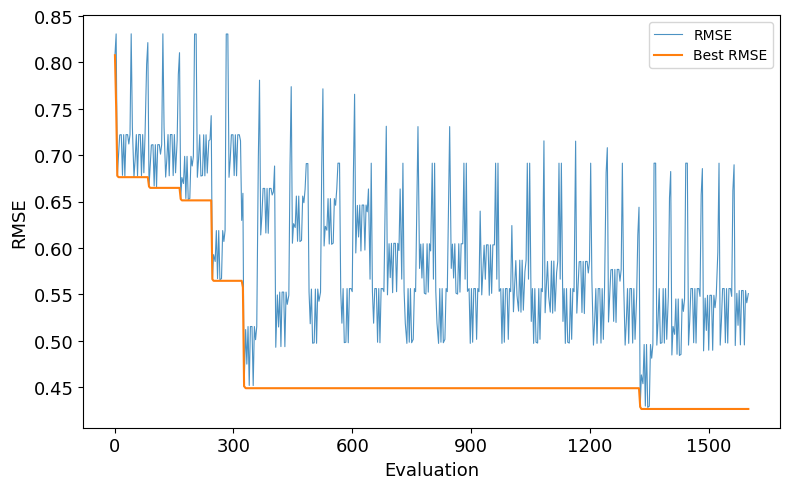

In [ ]:
from matplotlib.ticker import MaxNLocator

sample_idx = np.linspace(
    0,
    len(history_gs_V5_round1_df) - 1,
    500,
    dtype=int
)

plot_df = history_gs_V5_round1_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

# Round 2

### Halfing intervals to find value of minimum??

In [ ]:
%%time

parameter_results = []

grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [0.2, 0.5, 0.7]:
    for y_reg1 in [1, 20, 60, 100]:
        for e_reg1 in [0.001, 0.5]:
            for x_reg1 in [0.1, 5]:

                for alpha_reg2 in [0.2, 0.5, 0.7]:
                    for y_reg2 in [1, 20, 60, 100]:
                        for e_reg2 in [0.001, 0.5]:
                            for x_reg2 in [0.1, 5]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (p_i_year2 > 0.5).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


history_gs_V5_round2_df = pd.DataFrame(
    parameter_results,
    columns=[
        "alpha_reg1",
        "y_reg1",
        "e_reg1",
        "x_reg1",
        "alpha_reg2",
        "y_reg2",
        "e_reg2",
        "x_reg2",
        "rmse",
        "n_pred_year2"
    ]
)

history_gs_V5_round2_df.insert(
    0,
    "evaluation",
    range(1, len(history_gs_V5_round2_df) + 1)
)

history_gs_V5_round2_df["best_rmse"] = grid_best_history


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[8], abs(z[9] - 794))
)


print("alpha_reg1, y_reg1, e_reg1, x_reg1, "
      "alpha_reg2, y_reg2, e_reg2, x_reg2, "
      "rmse, n_pred_year2"
)

for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
0.2, 60, 0.5, 0.1, 0.2, 100, 0.001, 0.1, 0.4007, 606
0.2, 60, 0.5, 0.1, 0.2, 60, 0.001, 0.1, 0.4018, 630
0.2, 60, 0.5, 0.1, 0.7, 100, 0.001, 5, 0.4031, 635
0.2, 60, 0.5, 0.1, 0.2, 20, 0.5, 0.1, 0.4042, 538
0.2, 60, 0.5, 0.1, 0.2, 1, 0.5, 0.1, 0.4049, 636
0.2, 60, 0.5, 0.1, 0.7, 60, 0.001, 5, 0.4050, 635
0.2, 60, 0.5, 0.1, 0.2, 20, 0.001, 0.1, 0.4050, 636
0.2, 60, 0.5, 0.1, 0.5, 1, 0.001, 0.1, 0.4058, 535
0.2, 60, 0.5, 0.1, 0.7, 20, 0.5, 5, 0.4062, 594
0.2, 60, 0.5, 0.1, 0.7, 1, 0.5, 5, 0.4082, 635
0.2, 60, 0.5, 0.1, 0.7, 60, 0.5, 5, 0.4082, 594
0.2, 60, 0.5, 0.1, 0.7, 20, 0.001, 5, 0.4083, 635
0.2, 60, 0.5, 0.1, 0.5, 100, 0.001, 5, 0.4086, 639
0.2, 60, 0.5, 0.1, 0.5, 20, 0.5, 5, 0.4087, 635
0.2, 60, 0.5, 0.1, 0.7, 100, 0.5, 5, 0.4087, 592
0.2, 60, 0.5, 0.1, 0.5, 60, 0.5, 5, 0.4089, 635
0.2, 60, 0.5, 0.1, 0.5, 100, 0.5, 5, 0.4089, 635
0.2, 60, 0.5, 0.1, 0.7, 1, 0.001, 5, 0.4090, 635
0.2, 60, 0.5, 

In [ ]:
history_gs_V5_round2_df = pd.DataFrame({
    "run": range(1, len(parameter_results) + 1),
    "rmse": [z[8] for z in parameter_results]
})

history_gs_V5_round2_df["best_rmse"] = (
    history_gs_V5_round2_df["rmse"].cummin()
)

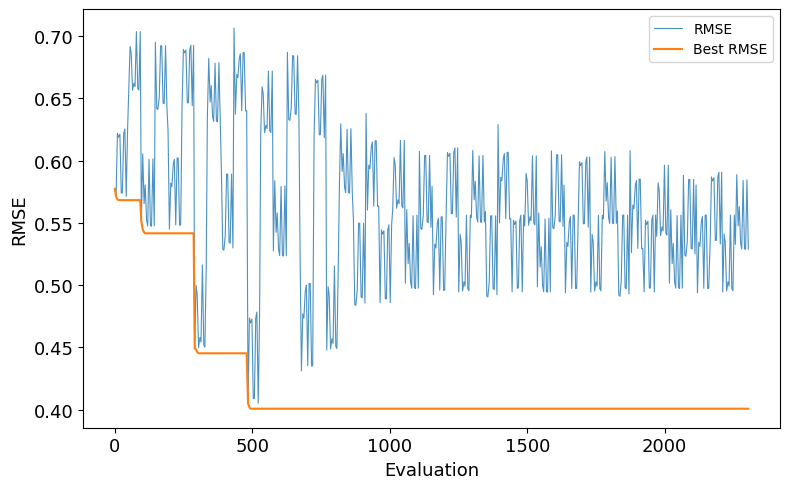

In [ ]:
# plot round 2

sample_idx = np.linspace(
    0,
    len(history_gs_V5_round2_df) - 1,
    500,
    dtype=int
)

plot_df = history_gs_V5_round2_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
# 0.2, 60, 0.5, 0.1, 0.2, 100, 0.001, 0.1, 0.4007, 606
# 0.2, 60, 0.5, 0.1, 0.2, 60, 0.001, 0.1, 0.4018, 630
# 0.2, 60, 0.5, 0.1, 0.7, 100, 0.001, 5, 0.4031, 635
# 0.2, 60, 0.5, 0.1, 0.2, 20, 0.5, 0.1, 0.4042, 538
# 0.2, 60, 0.5, 0.1, 0.2, 1, 0.5, 0.1, 0.4049, 636

In [ ]:
# for alpha_reg1 in [0.2, 0.5, 0.7]:
#     for y_reg1 in [1, 20, 60, 100]:
#         for e_reg1 in [0.001, 0.5]:
#             for x_reg1 in [0.1, 5]:

#                 for alpha_reg2 in [0.2, 0.5, 0.7]:
#                     for y_reg2 in [1, 20, 60, 100]:
#                         for e_reg2 in [0.001, 0.5]:
#                             for x_reg2 in [0.1, 5]:

# Round 3

In [ ]:
%%time

parameter_results = []

grid_rmse_history = []
grid_best_history = []

best_rmse_so_far = float("inf")

for alpha_reg1 in [0.1, 0.2, 0.3]:
    for y_reg1 in [40, 60, 80]:
        for e_reg1 in [0.25, 0.5, 0.75]:
            for x_reg1 in [0.01, 0.1, 0.5]:

                for alpha_reg2 in [0.1, 0.2, 0.3]:
                    for y_reg2 in [80, 100, 120]:
                        for e_reg2 in [0.0001, 0.001, 0.01]:
                            for x_reg2 in [0.01, 0.1, 0.5]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (p_i_year2 > 0.5).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (
        z[8],
        abs(z[9] - 794)
    )
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)


for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
0.2, 40, 0.75, 0.1, 0.2, 120, 0.001, 0.01, 0.3983, 753
0.2, 40, 0.75, 0.1, 0.2, 80, 0.01, 0.1, 0.3984, 748
0.2, 40, 0.75, 0.1, 0.2, 100, 0.001, 0.01, 0.3985, 757
0.2, 40, 0.75, 0.1, 0.2, 120, 0.001, 0.1, 0.3986, 759
0.2, 40, 0.5, 0.01, 0.2, 120, 0.001, 0.01, 0.3986, 675
0.2, 40, 0.75, 0.1, 0.2, 80, 0.001, 0.01, 0.3987, 760
0.2, 40, 0.5, 0.01, 0.2, 80, 0.01, 0.1, 0.3987, 670
0.2, 40, 0.75, 0.1, 0.2, 120, 0.01, 0.5, 0.3987, 760
0.2, 40, 0.5, 0.01, 0.2, 100, 0.001, 0.01, 0.3987, 679
0.2, 40, 0.75, 0.1, 0.2, 100, 0.001, 0.1, 0.3988, 760
0.2, 40, 0.5, 0.01, 0.2, 120, 0.001, 0.1, 0.3989, 681
0.2, 40, 0.75, 0.1, 0.2, 100, 0.01, 0.5, 0.3989, 760
0.2, 40, 0.5, 0.01, 0.2, 80, 0.001, 0.01, 0.3990, 682
0.2, 40, 0.5, 0.01, 0.2, 120, 0.01, 0.5, 0.3990, 682
0.2, 40, 0.5, 0.01, 0.2, 100, 0.001, 0.1, 0.3990, 682
0.2, 80, 0.25, 0.1, 0.2, 120, 0.001, 0.01, 0.3991, 613
0.2, 60, 0.25, 0.01, 0.2, 120, 0.001, 0.01, 0.3

In [ ]:
history_gs_V5_round3_df = pd.DataFrame({
    "evaluation": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

In [ ]:
history_gs_V5_round3_df.describe()

,evaluation,rmse,best_rmse
count,6561.00000,6561.000000,6561.000000
mean,3281.00000,0.485154,0.434177
std,1894.14189,0.048087,0.050885
min,1.00000,0.398312,0.398312
25%,1641.00000,0.444727,0.398312
50%,3281.00000,0.489377,0.398312
75%,4921.00000,0.520850,0.494133
max,6561.00000,0.611095,0.550459


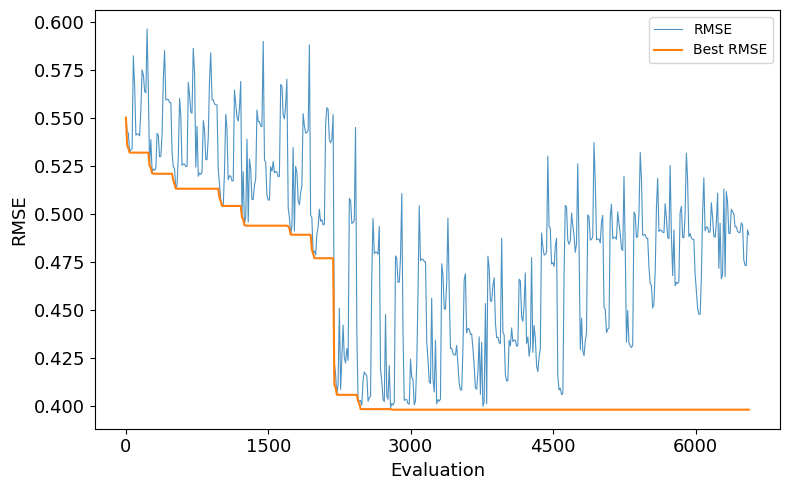

In [ ]:
# plot round 3

sample_idx = np.linspace(
    0,
    len(history_gs_V5_round3_df) - 1,
    500,
    dtype=int
)

plot_df = history_gs_V5_round3_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
# 0.2, 40, 0.75, 0.1, 0.2, 120, 0.001, 0.01, 0.3983, 753
# 0.2, 40, 0.75, 0.1, 0.2, 80, 0.01, 0.1, 0.3984, 748
# 0.2, 40, 0.75, 0.1, 0.2, 100, 0.001, 0.01, 0.3985, 757
# 0.2, 40, 0.75, 0.1, 0.2, 120, 0.001, 0.1, 0.3986, 759
# 0.2, 40, 0.5, 0.01, 0.2, 120, 0.001, 0.01, 0.3986, 675
# 0.2, 40, 0.75, 0.1, 0.2, 80, 0.001, 0.01, 0.3987, 760

## Round 4

In [ ]:
%%time

parameter_results = []

grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [0.15, 0.2]:
    for y_reg1 in [30, 40]:
        for e_reg1 in [0.75, 0.875]:
            for x_reg1 in [0.05, 0.1]:

                for alpha_reg2 in [0.15, 0.2]:
                    for y_reg2 in [120, 130]:
                        for e_reg2 in [0.001, 0.0055]:
                            for x_reg2 in [0.005, 0.01]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (
                                    p_i_year2 > 0.5
                                ).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


history_gs_V5_round4_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[8], abs(z[9] - 794))
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)


for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
0.2, 40, 0.75, 0.1, 0.15, 130, 0.0055, 0.005, 0.3970, 760
0.2, 40, 0.875, 0.1, 0.15, 130, 0.0055, 0.005, 0.3971, 676
0.2, 40, 0.75, 0.1, 0.15, 130, 0.0055, 0.01, 0.3971, 760
0.2, 40, 0.875, 0.1, 0.15, 130, 0.0055, 0.01, 0.3971, 676
0.2, 40, 0.75, 0.1, 0.15, 120, 0.0055, 0.005, 0.3972, 760
0.2, 40, 0.875, 0.1, 0.15, 120, 0.0055, 0.005, 0.3973, 676
0.2, 40, 0.75, 0.1, 0.15, 120, 0.0055, 0.01, 0.3973, 761
0.2, 40, 0.875, 0.1, 0.15, 120, 0.0055, 0.01, 0.3973, 677
0.2, 30, 0.875, 0.05, 0.15, 130, 0.0055, 0.005, 0.3979, 820
0.2, 30, 0.875, 0.05, 0.15, 130, 0.0055, 0.01, 0.3979, 820
0.2, 40, 0.75, 0.05, 0.15, 130, 0.0055, 0.005, 0.3980, 621
0.2, 40, 0.75, 0.05, 0.15, 130, 0.0055, 0.01, 0.3981, 621
0.2, 30, 0.875, 0.05, 0.15, 120, 0.0055, 0.005, 0.3981, 820
0.2, 30, 0.875, 0.05, 0.15, 120, 0.0055, 0.01, 0.3982, 821
0.2, 40, 0.75, 0.05, 0.15, 120, 0.0055, 0.005, 0.3982, 621
0.2, 40, 0.75, 0.1, 0.2, 130, 0

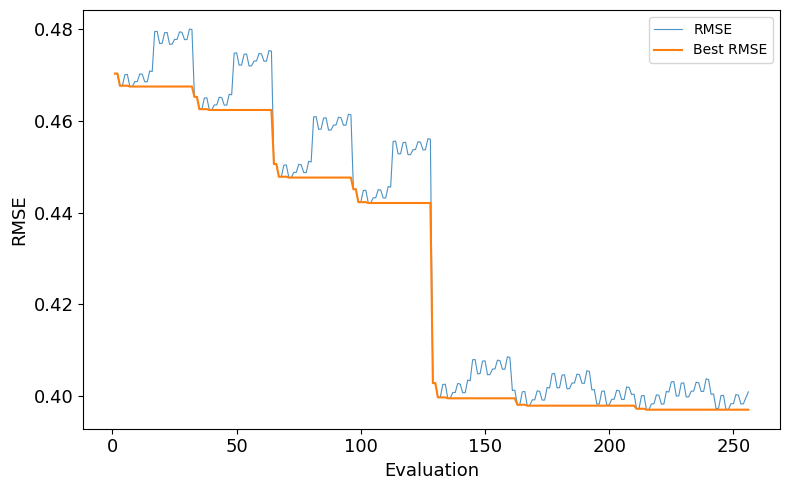

In [ ]:
# plot round 4

sample_idx = np.linspace(
    0,
    len(history_gs_V5_round4_df) - 1,
    255,
    dtype=int
)

plot_df = history_gs_V5_round4_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

## Round 5

In [ ]:
%%time

parameter_results = []

grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [0.2, 0.225]:
    for y_reg1 in [40, 45]:
        for e_reg1 in [0.6875, 0.75, 0.8125]:
            for x_reg1 in [0.1, 0.125]:

                for alpha_reg2 in [0.125, 0.15, 0.175]:
                    for y_reg2 in [125, 130, 135]:
                        for e_reg2 in [0.0055, 0.00775]:
                            for x_reg2 in [0.0025, 0.005]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (
                                    p_i_year2 > 0.5
                                ).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


history_gs_V5_round5_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[8], abs(z[9] - 794))
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)


for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:30]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
0.2, 45, 0.75, 0.125, 0.15, 135, 0.00775, 0.0025, 0.3964, 716
0.2, 45, 0.75, 0.125, 0.15, 135, 0.00775, 0.005, 0.3964, 716
0.2, 45, 0.75, 0.125, 0.15, 130, 0.00775, 0.0025, 0.3965, 717
0.2, 45, 0.75, 0.125, 0.15, 130, 0.00775, 0.005, 0.3965, 717
0.2, 40, 0.8125, 0.1, 0.15, 135, 0.00775, 0.0025, 0.3965, 727
0.2, 45, 0.6875, 0.125, 0.15, 135, 0.00775, 0.0025, 0.3965, 758
0.2, 40, 0.8125, 0.1, 0.15, 135, 0.00775, 0.005, 0.3965, 727
0.2, 45, 0.6875, 0.125, 0.15, 135, 0.00775, 0.005, 0.3965, 758
0.2, 45, 0.75, 0.125, 0.15, 125, 0.00775, 0.0025, 0.3965, 717
0.2, 45, 0.75, 0.125, 0.15, 125, 0.00775, 0.005, 0.3966, 717
0.2, 40, 0.8125, 0.1, 0.15, 130, 0.00775, 0.0025, 0.3966, 728
0.2, 45, 0.6875, 0.125, 0.15, 130, 0.00775, 0.0025, 0.3966, 759
0.2, 45, 0.6875, 0.1, 0.15, 135, 0.00775, 0.0025, 0.3966, 677
0.2, 40, 0.8125, 0.1, 0.15, 130, 0.00775, 0.005, 0.3966, 728
0.2, 45, 0.6875, 0.125, 0.15, 130, 0.0077

In [ ]:
# best_params_gs_V5 = {
#     "alpha_reg1": 0.2,
#     "y_reg1": 45,
#     "e_reg1": 0.75,
#     "x_reg1": 0.125,

#     "alpha_reg2": 0.15,
#     "y_reg2": 135,
#     "e_reg2": 0.00775,
#     "x_reg2": 0.0025
# }

# "x_reg2" : 0.005

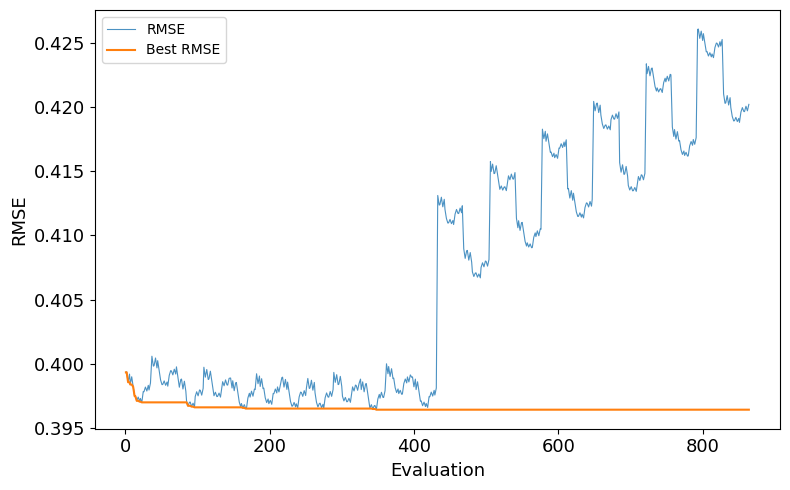

In [ ]:
# plot round 5

sample_idx = np.linspace(
    0,
    len(history_gs_V5_round5_df) - 1,
    500,
    dtype=int
)

plot_df = history_gs_V5_round5_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

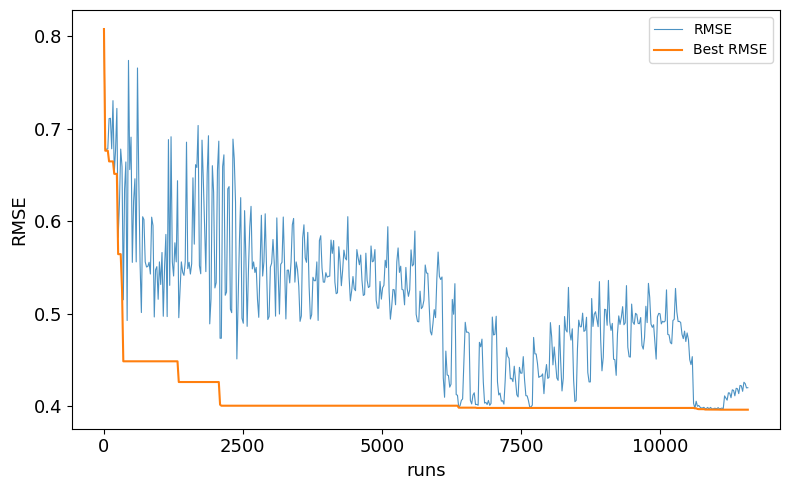

In [ ]:
# plot all 5 rounds

sample_idx = np.linspace(
    0,
    len(history_gs_V5_all_df) - 1,
    500,
    dtype=int
)

plot_df = history_gs_V5_all_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["global_run"],
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df["global_run"],
    plot_df["global_best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("runs", fontsize=13)
plt.ylabel("RMSE", fontsize=13)

plt.tick_params(labelsize=13)
plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
history_gs_V5_all_df.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_grid_search_V5_all_history.csv", index=False)



---


# ?? Questions

In [ ]:
print((np.where(region == 1, 1, 0)*p_i_year2).mean())
print((np.where(region == 1, 0, 1)*p_i_year2).mean())

9.24872452277208e-07
0.001972666188758703


In [ ]:
print(p_i_year2[region == 1].mean())
print(p_i_year2[region != 1].mean())

1.6695833931051988e-06
0.004422562538466017


In [ ]:
print((region == 1).sum())
print((region != 1).sum())

1422
1145


In [ ]:
print(obsyear2[region == 1].mean())
print(obsyear2[region != 1].mean())

0.3227848101265823
0.2925764192139738
